In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/glass.csv")
print("Shape:", df.shape)

Shape: (214, 10)


In [12]:
print("Rows and Columns:", df.shape)
print("Column Names:", df.columns.tolist())
df.head()

Rows and Columns: (214, 10)
Column Names: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


* Which column is the output we want to predict?
--> Type

* Are all columns numeric?
-->all columns are numeric
* Is there an ID column that should not be used
--> yes, which is not useful,so will remove it

In [13]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("Id column removed.")

In [14]:
# 1 = Type 1 glass, 0 = everything else
df["y"] = (df["Type"] == 1).astype(int)
df = df.drop(columns=["Type"])

print(df["y"].value_counts())

y
0    144
1     70
Name: count, dtype: int64


In [15]:
X = df.drop(columns=["y"]).values
y = df["y"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (214, 9)
y shape: (214,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 171
Testing samples: 43


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("train mean (should be ~0):", X_train.mean().round(4))
print("train std  (should be ~1):", X_train.std().round(4))

train mean (should be ~0): -0.0
train std  (should be ~1): 1.0


# sigmoid function

In [19]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("sigmoid(0)  =", sigmoid(0))
print("sigmoid(5)  =", sigmoid(5).round(4))
print("sigmoid(-5) =", sigmoid(-5).round(4))

sigmoid(0)  = 0.5
sigmoid(5)  = 0.9933
sigmoid(-5) = 0.0067


# forward computation

In [20]:

def predict_proba(X, w, b):
    z = X @ w + b   # weighted sum
    p = sigmoid(z)  # convert to probability
    return p

# loss function
- We measure how wrong the model's confidence is, not just whether the label was right. Being confidently wrong gets a huge penalty. This pushes the model to be accurate AND honest about uncertainty.

In [21]:
def loss(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# Test it
print("confident and correct:", loss(np.array([1]), np.array([0.99])).round(4))
print("uncertain:            ", loss(np.array([1]), np.array([0.50])).round(4))
print("confident and wrong:  ", loss(np.array([1]), np.array([0.01])).round(4))

confident and correct: 0.0101
uncertain:             0.6931
confident and wrong:   4.6052


- update weights

In [22]:
def update_weights(X, y, w, b, lr):
    p = predict_proba(X, w, b)
    error = p - y
    w = w - lr * (X.T @ error) / len(y)
    b = b - lr * np.mean(error)
    return w, b

# training Loop
- repeat the update 100 times. Each pass the model gets a little better. The loss going down in the plot confirms it's actually learning.

In [24]:
w = np.zeros(X_train.shape[1])
b = 0.0
lr = 0.1
epochs = 100
loss_history = []

for epoch in range(epochs):
    w, b = update_weights(X_train, y_train, w, b, lr)
    if epoch % 10 == 0:
        p = predict_proba(X_train, w, b)
        l = loss(y_train, p)
        loss_history.append(l)
        print(f"Epoch {epoch:3d} | Loss: {l:.4f}")

print("training complete!")

Epoch   0 | Loss: 0.6822
Epoch  10 | Loss: 0.6107
Epoch  20 | Loss: 0.5748
Epoch  30 | Loss: 0.5529
Epoch  40 | Loss: 0.5379
Epoch  50 | Loss: 0.5269
Epoch  60 | Loss: 0.5184
Epoch  70 | Loss: 0.5116
Epoch  80 | Loss: 0.5060
Epoch  90 | Loss: 0.5014
training complete!


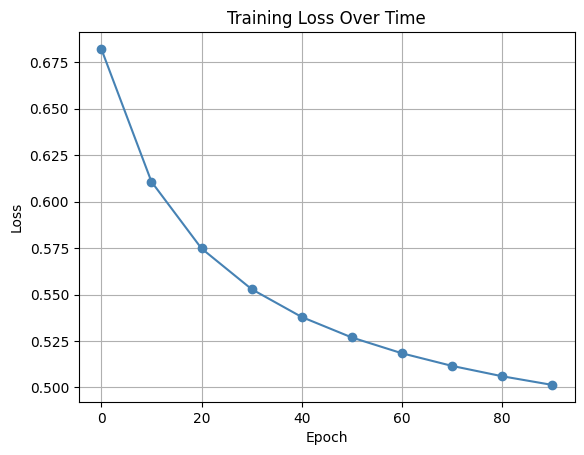

In [25]:
import matplotlib.pyplot as plt
plt.plot(range(0, 100, 10), loss_history, marker='o', color='steelblue')
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [26]:
def predict_label(p, threshold=0.5):
    return (p >= threshold).astype(int)

p_test = predict_proba(X_test, w, b)

labels_05 = predict_label(p_test, threshold=0.5)
labels_07 = predict_label(p_test, threshold=0.7)

print(f"accuracy at threshold 0.5: {np.mean(labels_05 == y_test)*100:.2f}%")
print(f"accuracy at threshold 0.7: {np.mean(labels_07 == y_test)*100:.2f}%")


print("\nsample | true | probability | pred@0.5 | pred@0.7")
print("-" * 55)
for i in range(10):
    print(f"  {i+1:2d}   |  {y_test[i]}   |   {p_test[i]:.3f}     |    {labels_05[i]}     |    {labels_07[i]}")

accuracy at threshold 0.5: 86.05%
accuracy at threshold 0.7: 72.09%

sample | true | probability | pred@0.5 | pred@0.7
-------------------------------------------------------
   1   |  1   |   0.466     |    0     |    0
   2   |  0   |   0.027     |    0     |    0
   3   |  1   |   0.608     |    1     |    0
   4   |  0   |   0.022     |    0     |    0
   5   |  0   |   0.309     |    0     |    0
   6   |  0   |   0.301     |    0     |    0
   7   |  1   |   0.551     |    1     |    0
   8   |  0   |   0.442     |    0     |    0
   9   |  0   |   0.438     |    0     |    0
  10   |  0   |   0.406     |    0     |    0


The model gives a probability. We decide the cutoff for YES. A higher threshold means we only say YES when very confident which matters in quality control where mistakes are costly.

 # How is this different from a perceptron?
- The perceptron just says YES or NO. Logistic regression gives a probability — like "73% chance it's Type 1". That extra information is useful, and it also makes learning smoother because sigmoid has a gradient we can actually work with.

 # Why does sigmoid matter?
- It keeps the output between 0 and 1, so we can read it as a probability. The step function used in perceptron throws away all that detail you just get a hard cut at the boundary.

# What problem still remains unsolved?
- Logistic regression can only draw a straight line between classes. If the data is mixed in a way that no straight line can separate it, this model will always get it wrong. That's the problem neural networks are built to fix.

